# Tópico 04 – Estimação Pontual (EMV) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29/images/colag_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 6.5%;">](https://colab.research.google.com/github/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29/images/github_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 3.25%;">](https://github.com/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29/T%C3%B3pico%2004%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28EMV%29.ipynb)




### MATERIAL EM CONSTRUÇÃO [!]

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports para esse tópico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
import math as math
plt.style.use('ggplot')

## Opções de como printar objetos do Numpy e do Pandas
np.set_printoptions(threshold = 20, precision = 2, suppress = True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

## Exemplo #1: $Poisson(\lambda)$

In [2]:
"""
Exemplo #1: Y_i ~ iid. Poisson(lambda)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Parâmetros da simulação
## NOTA: no Python, a palavra "lambda" é reservada! 
lam = 2 # taxa da Poisson 

## Gerando as observações
vY = np.random.poisson(lam = lam, size = n)

In [3]:
## Amostra simulada
vY

array([4, 1, 3, ..., 3, 2, 4], shape=(1000,))

In [4]:
## Função de log-verossimilhança
## NOTA: essa função na verdade retorna o *negativo* da log-verossimilhança
def neg_loglike(lam, vY):
    return -np.sum(- lam  + vY * np.log(lam) - gammaln(vY + 1))

In [5]:
## Verossimilhança avaliada no mínimo
neg_loglike(lam, vY)

np.float64(1709.861692148421)

In [6]:
## Otimização!
lam_0 = 4.0 # valor inicial
out = minimize(neg_loglike,
               lam_0, 
               args = (vY, ), 
               method = 'L-BFGS-B',
               bounds = [(1e-5, 1e5)])

## Resultados
print("EMV de lambda:", out.x[0])
out

EMV de lambda: 2.003000045066568


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1709.8594432725786
        x: [ 2.003e+00]
      nit: 6
      jac: [ 4.547e-05]
     nfev: 18
     njev: 9
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [7]:
## EMV analítico (p/ comparação)
vY.mean()

np.float64(2.003)

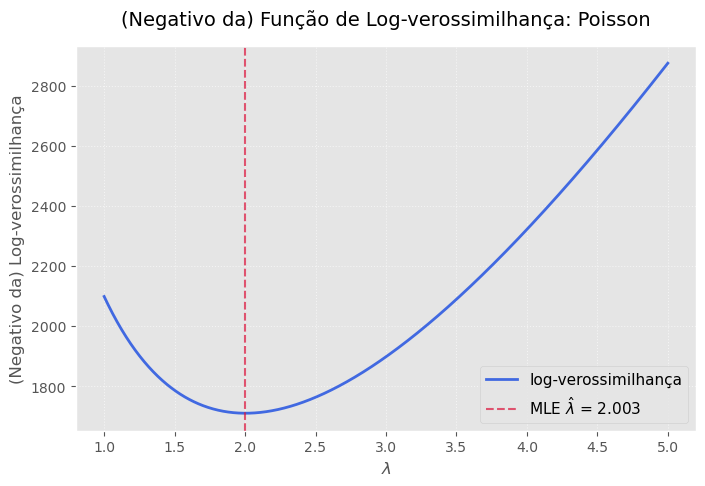

In [8]:
## Visualizando (o negativo da) log-verossimilhança
# grade de valores
lambda_grid = np.linspace(1.00, 5.00, int(1e3))
neg_loglike_values = [neg_loglike(l, vY) for l in lambda_grid]

## log-verossimilhança avaliada no EMV
mle_lambda = out.x[0]
min_nll = neg_loglike(mle_lambda, vY)

## Gráfico
plt.figure(figsize = (8, 5))
plt.plot(lambda_grid, neg_loglike_values, 
         label = 'log-verossimilhança', color = 'royalblue', lw = 2)
plt.axvline(mle_lambda, color = 'crimson', linestyle = '--', 
            alpha = 0.7, label=f'MLE $\hat{{\lambda}}$ = {mle_lambda:.3f}')
plt.title('(Negativo da) Função de Log-verossimilhança: Poisson', fontsize=14, pad=15)
plt.xlabel('$\lambda$', fontsize=12)
plt.ylabel('(Negativo da) Log-verossimilhança', fontsize=12)
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.legend(fontsize = 11)
plt.show()

In [9]:
## Distribuição amostral do EMV

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Quantidade de amostras independentes
m = int(1e3)

## Parâmetros da simulação
lam = 2 # taxa da Poisson

## Declarando objetos
vMLE = np.zeros(m)

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.poisson(lam = lam, size = n) # gerando amostra
    lam_0 = np.random.uniform(low = 1.0, high = 10.0, size = 1) # valor inicial (aleatorizado)
    out = minimize(neg_loglike, 
                   lam_0, 
                   args = (vY, ),
                   method = 'L-BFGS-B',
                   bounds = [(1e-5, 1e5)]) # otimização
    vMLE[j] = out.x[0] # EMV

In [10]:
## EMVs
vMLE

array([2.  , 1.98, 1.89, ..., 1.99, 2.01, 1.98], shape=(1000,))

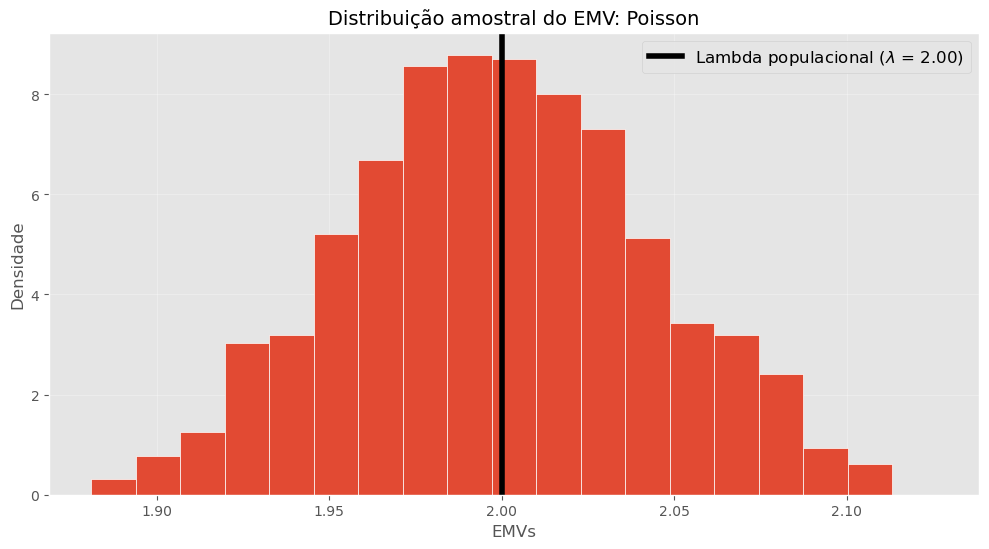

In [11]:
## Visualizando a distribuição amostral do EMV
plt.figure(figsize = (12, 6))
plt.hist(vMLE, 
         bins = np.arange(vMLE.min(), vMLE.max(), (vMLE.max() - vMLE.min())/20), 
         density = True, 
         ec = 'w')
plt.axvline(lam, color = 'black', linewidth = 4, label = f'Lambda populacional ($\lambda$ = {lam:.2f})')
plt.title('Distribuição amostral do EMV: Poisson', fontsize = 14)
plt.xlabel('EMVs', fontsize = 12)
plt.ylabel('Densidade', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

## Exemplo #1: $Beta(\alpha, 1)$

In [12]:
"""
Exemplo #1: Y_i ~ iid. Beta(\alpha, 1)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Parâmetros da simulação
alpha = 1./2 # forma da Beta

## Gerando as observações
vY = np.random.beta(a = alpha, b = 1, size = n)

In [13]:
## Amostra simulada
vY

array([0.13, 0.  , 0.  , ..., 0.01, 0.16, 0.59], shape=(1000,))

In [14]:
## Função de log-verossimilhança
## NOTA: essa função na verdade retorna o *negativo* da log-verossimilhança
def neg_loglike(alpha, vY):
    return -np.sum(np.log(alpha) + (alpha - 1)*np.log(vY))

In [15]:
## Verossimilhança avaliada no mínimo
neg_loglike(alpha, vY)

np.float64(-379.0560682009892)

In [16]:
## Otimização!
alpha_0 = 1.0 # valor inicial
out = minimize(neg_loglike,
               alpha_0, 
               args = (vY, ), 
               method = 'L-BFGS-B',
               bounds = [(1e-5, 1e5)])

## Resultados
print("EMV de alpha:", out.x[0])
out

EMV de alpha: 0.4663294884526297


  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -381.54367455993827
        x: [ 4.663e-01]
      nit: 6
      jac: [ 0.000e+00]
     nfev: 18
     njev: 9
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [17]:
## EMV analítico (p/ comparação)
-n/np.sum(np.log(vY))

np.float64(0.4663294954364416)

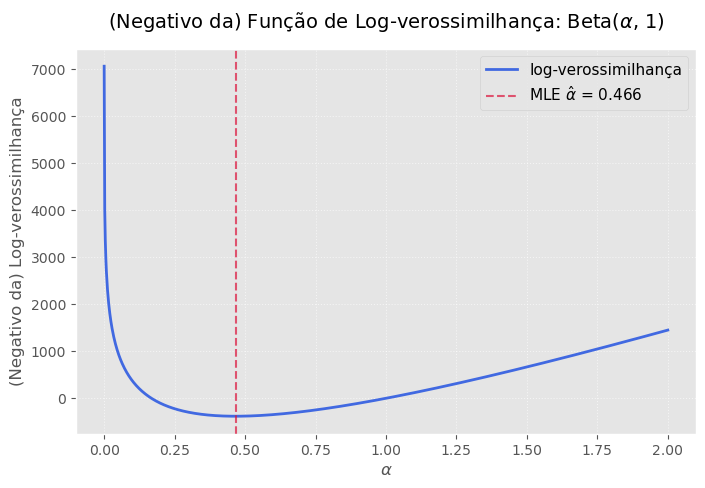

In [18]:
## Visualizando (o negativo da) log-verossimilhança
# grade de valores
alpha_grid = np.linspace(1e-4, 2.00, int(1e3))
neg_loglike_values = [neg_loglike(a, vY) for a in alpha_grid]

## log-verossimilhança avaliada no EMV
mle_alpha = out.x[0]
min_nll = neg_loglike(mle_alpha, vY)

# ## Gráfico
plt.figure(figsize = (8, 5))
plt.plot(alpha_grid, neg_loglike_values, 
         label = 'log-verossimilhança', color = 'royalblue', lw = 2)
plt.axvline(mle_alpha, color = 'crimson', linestyle = '--', 
            alpha = 0.7, label=f'MLE $\hat{{\\alpha}}$ = {mle_alpha:.3f}')
plt.title('(Negativo da) Função de Log-verossimilhança: Beta($\\alpha$, 1)', fontsize=14, pad=15)
plt.xlabel('$\\alpha$', fontsize=12)
plt.ylabel('(Negativo da) Log-verossimilhança', fontsize=12)
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.legend(fontsize = 11)
plt.show()

In [19]:
## Distribuição amostral do EMV

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Quantidade de amostras independentes
m = int(1e3)

## Parâmetros da simulação
alpha = 1./2 # forma da Beta

## Declarando objetos
vMLE = np.zeros(m)

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.beta(a = alpha, b = 1, size = n) # gerando amostra
    alpha_0 = np.random.uniform(low = 1.0, high = 4.0, size = 1) # valor inicial (aleatorizado)
    out = minimize(neg_loglike, 
                   alpha_0, 
                   args = (vY, ),
                   method = 'L-BFGS-B',
                   bounds = [(1e-5, 1e5)]) # otimização
    vMLE[j] = out.x[0] # EMV

In [20]:
## EMVs
vMLE

array([0.47, 0.49, 0.52, ..., 0.51, 0.51, 0.51], shape=(1000,))

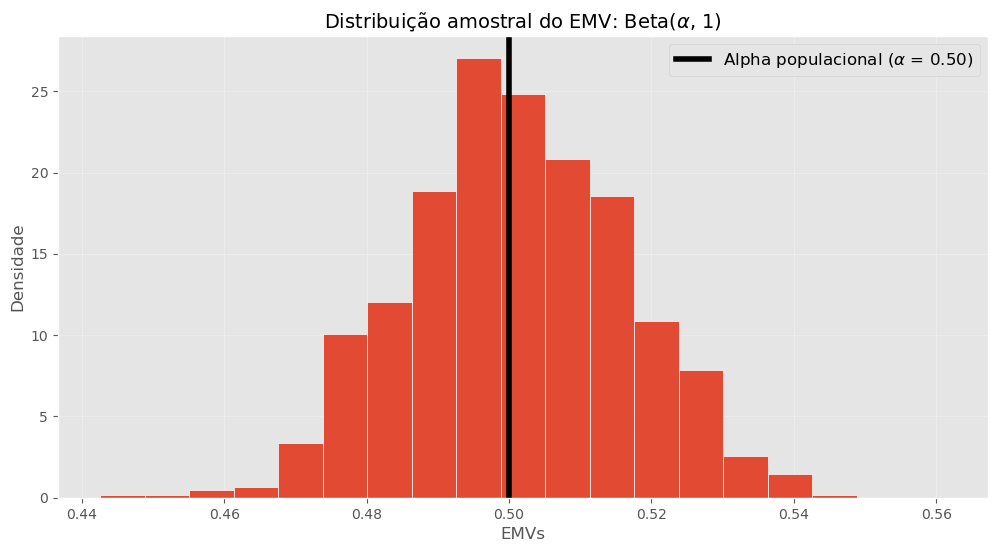

In [21]:
## Visualizando a distribuição amostral do EMV
plt.figure(figsize = (12, 6))
plt.hist(vMLE, 
         bins = np.arange(vMLE.min(), vMLE.max(), (vMLE.max() - vMLE.min())/20), 
         density = True, 
         ec = 'w')
plt.axvline(alpha, color = 'black', linewidth = 4, label = f'Alpha populacional ($\\alpha$ = {alpha:.2f})')
plt.title('Distribuição amostral do EMV: Beta($\\alpha$, 1)', fontsize = 14)
plt.xlabel('EMVs', fontsize = 12)
plt.ylabel('Densidade', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()